=============================================================================
Notebook 02: Layer 1 — Nutrition Outcomes (WHA 6 Targets)
Global Nutrition Monitoring Framework — UNICEF Conceptual Framework Project
Adam T. Bailes, MPH | August 2026
=============================================================================

PURPOSE
-------
Analyze and visualize country and regional progress toward the 6 WHO World
Health Assembly global nutrition targets for 2030. This corresponds to the
OUTCOMES level of the UNICEF Conceptual Framework.

OUTPUTS
-------
  - Regional trend lines for all 6 WHA targets (2000-2024)
  - Country progress classification: on track / insufficient / no data
  - Choropleth maps by indicator (for Tableau)
  - Regional summary tables
=============================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
print(os.getcwd())
print(os.listdir('../data/processed'))

C:\Users\adamt\Jobs\Personal_Projects\gnmf_project\notebooks
['data_gap_matrix.csv', 'latest_values_by_country.csv', 'unicef_sdmx_clean.csv']


In [3]:
DATA_PROC = '../data/processed'
FIGURES   = '../outputs/figures'
TABLES    = '../outputs/tables'
os.makedirs(FIGURES, exist_ok=True)
os.makedirs(TABLES, exist_ok=True)

In [4]:
# --- Style ---
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150
})

In [5]:
UNICEF_BLUE   = '#1CABE2'
UNICEF_NAVY   = '#374EA2'
UNICEF_GREEN  = '#00833D'
UNICEF_ORANGE = '#F26A21'
UNICEF_RED    = '#E2231A'
UNICEF_PURPLE = '#6A1E74'

In [6]:
print("=" * 70)
print("NOTEBOOK 02: LAYER 1 — NUTRITION OUTCOMES (WHA 6 TARGETS)")
print("=" * 70)

NOTEBOOK 02: LAYER 1 — NUTRITION OUTCOMES (WHA 6 TARGETS)


In [7]:
# --- Load data ---
try:
    df = pd.read_csv(f'{DATA_PROC}/unicef_sdmx_clean.csv')
    df_latest = pd.read_csv(f'{DATA_PROC}/latest_values_by_country.csv')
except FileNotFoundError:
    print("ERROR: Run 01_data_cleaning.py first.")
    raise

In [8]:
# Layer 1 indicators only
LAYER1_CODES = {
    'NT_ANT_HAZ_NE2_MOD':   'Stunting',
    'NT_ANT_WHZ_NE2_MOD':   'Wasting',
    'NT_ANT_WHZ_PO2_MOD':   'Overweight',
    'NT_ANE_WOM_15_49_MOD': 'Anaemia (WRA)',
    'NT_BF_EXBF':           'Excl. Breastfeeding',
    'NT_BW_LBW':            'Low Birth Weight',
}

In [9]:
# WHA 2030 targets
WHA_TARGETS_2030 = {
    'NT_ANT_HAZ_NE2_MOD':   {'target': 10.0,  'direction': 'decrease', 'label': '≤10%'},
    'NT_ANT_WHZ_NE2_MOD':   {'target': 3.0,   'direction': 'decrease', 'label': '<3%'},
    'NT_ANT_WHZ_PO2_MOD':   {'target': None,  'direction': 'decrease', 'label': 'No increase'},
    'NT_ANE_WOM_15_49_MOD': {'target': 50,    'direction': 'decrease', 'label': '50% reduction'},
    'NT_BF_EXBF':           {'target': 60.0,  'direction': 'increase', 'label': '≥60%'},
    'NT_BW_LBW':            {'target': 30,    'direction': 'decrease', 'label': '30% reduction'},
}

In [10]:
df_l1 = df[df['indicator'].isin(LAYER1_CODES.keys())].copy()
df_l1_latest = df_latest[df_latest['indicator'].isin(LAYER1_CODES.keys())].copy()
df_l1_latest['indicator_short'] = df_l1_latest['indicator'].map(LAYER1_CODES)

=============================================================================
FIGURE 1: Regional trend lines — WHA 6 targets (2000-2024)
=============================================================================

In [11]:
print("\n[1] Generating regional trend lines...")


[1] Generating regional trend lines...


In [12]:
REGION_COLORS = {
    'Eastern and Southern Africa':  UNICEF_BLUE,
    'West and Central Africa':      UNICEF_ORANGE,
    'South Asia':                   UNICEF_PURPLE,
    'East Asia and Pacific':        UNICEF_GREEN,
    'Middle East and North Africa': '#E8A838',
    'Latin America and Caribbean':  '#00AED9',
    'Europe and Central Asia':      '#80BD41',
    'North America':                '#999999',
}

Text(0.5, 1.01, 'Progress Toward WHO/UNICEF Global Nutrition Targets (2030)\nUNICEF Conceptual Framework — Layer 1: Nutrition Outcomes')

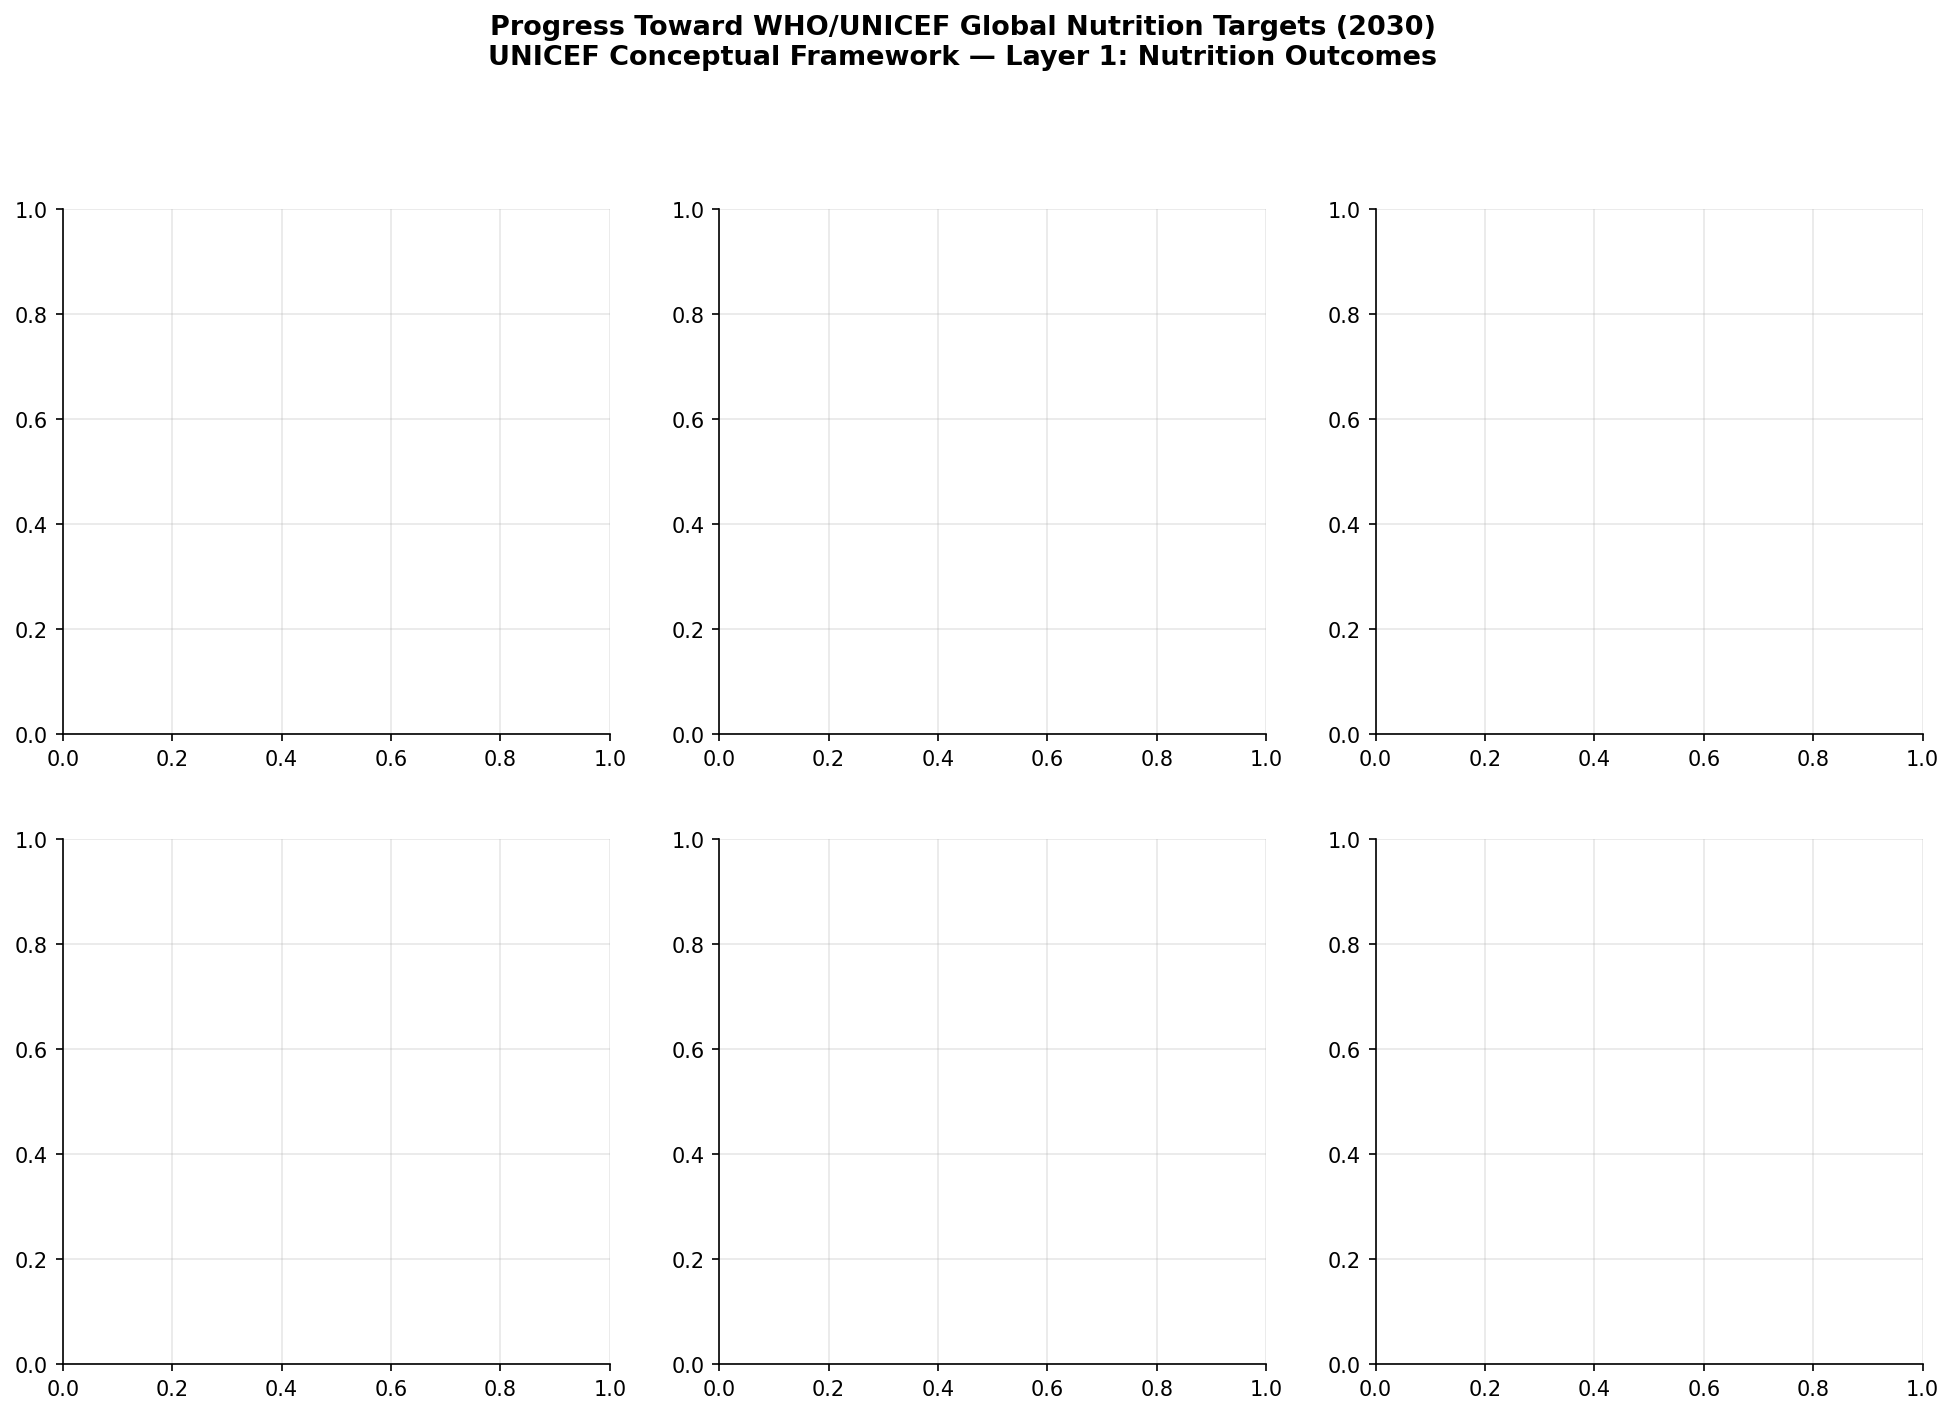

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Progress Toward WHO/UNICEF Global Nutrition Targets (2030)\nUNICEF Conceptual Framework — Layer 1: Nutrition Outcomes',
    fontsize=13, fontweight='bold', y=1.01
)

In [14]:
axes_flat = axes.flatten()

In [15]:
for idx, (code, short_name) in enumerate(LAYER1_CODES.items()):
    ax = axes_flat[idx]
    df_ind = df_l1[df_l1['indicator'] == code].copy()

    if 'region' not in df_ind.columns or df_ind['region'].isna().all():
        ax.text(0.5, 0.5, 'No regional data', transform=ax.transAxes, ha='center')
        ax.set_title(short_name)
        continue

    df_reg = (df_ind.groupby(['year', 'region'])['value']
              .median()
              .reset_index())

    for region, color in REGION_COLORS.items():
        df_r = df_reg[df_reg['region'] == region].sort_values('year')
        if len(df_r) >= 3:
            ax.plot(df_r['year'], df_r['value'],
                    color=color, linewidth=1.8,
                    label=region.replace(' and ', ' & '))

    # Add 2030 target line
    tgt = WHA_TARGETS_2030.get(code, {})
    if tgt.get('target'):
        ax.axhline(tgt['target'], color='red', linestyle='--',
                   linewidth=1.2, alpha=0.7,
                   label=f"2030 target: {tgt['label']}")

    ax.set_title(short_name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('%', fontsize=9)
    ax.set_xlim(2000, 2024)
    ax.tick_params(labelsize=8)

In [16]:
# Shared legend
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           fontsize=8, bbox_to_anchor=(0.5, -0.05),
           frameon=True, fancybox=True)

In [17]:
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig01_wha6_regional_trends.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("  Saved: fig01_wha6_regional_trends.png")

<Figure size 960x720 with 0 Axes>

  Saved: fig01_wha6_regional_trends.png


=============================================================================
FIGURE 2: Country progress classification heatmap
=============================================================================

In [18]:
print("\n[2] Generating country progress classification...")


[2] Generating country progress classification...


In [19]:
def classify_progress(row, targets=WHA_TARGETS_2030):
    """Classify country progress toward 2030 target."""
    code = row['indicator']
    val  = row['value']
    yr   = row.get('year', None)
    tgt  = targets.get(code, {})

    if pd.isna(val):
        return 'No data'
    if pd.isna(yr) or (2024 - yr) > 7:
        return 'Data outdated'

    target_val = tgt.get('target')
    direction  = tgt.get('direction', 'decrease')

    if target_val is None:
        return 'Monitor (no numeric target)'

    if direction == 'decrease':
        if val <= target_val:
            return 'On track'
        elif val <= target_val * 1.5:
            return 'Insufficient progress'
        else:
            return 'Off track'
    else:  # increase (EBF target)
        if val >= target_val:
            return 'On track'
        elif val >= target_val * 0.75:
            return 'Insufficient progress'
        else:
            return 'Off track'

In [20]:
df_l1_latest['progress'] = df_l1_latest.apply(classify_progress, axis=1)

In [21]:
# Summary by indicator
progress_summary = (df_l1_latest
                    .groupby(['indicator_short', 'progress'])
                    .size()
                    .unstack(fill_value=0))

In [22]:
COLOR_MAP = {
    'On track':               UNICEF_GREEN,
    'Insufficient progress':  UNICEF_ORANGE,
    'Off track':              UNICEF_RED,
    'No data':                '#CCCCCC',
    'Data outdated':          '#AAAAAA',
    'Monitor (no numeric target)': UNICEF_BLUE,
}

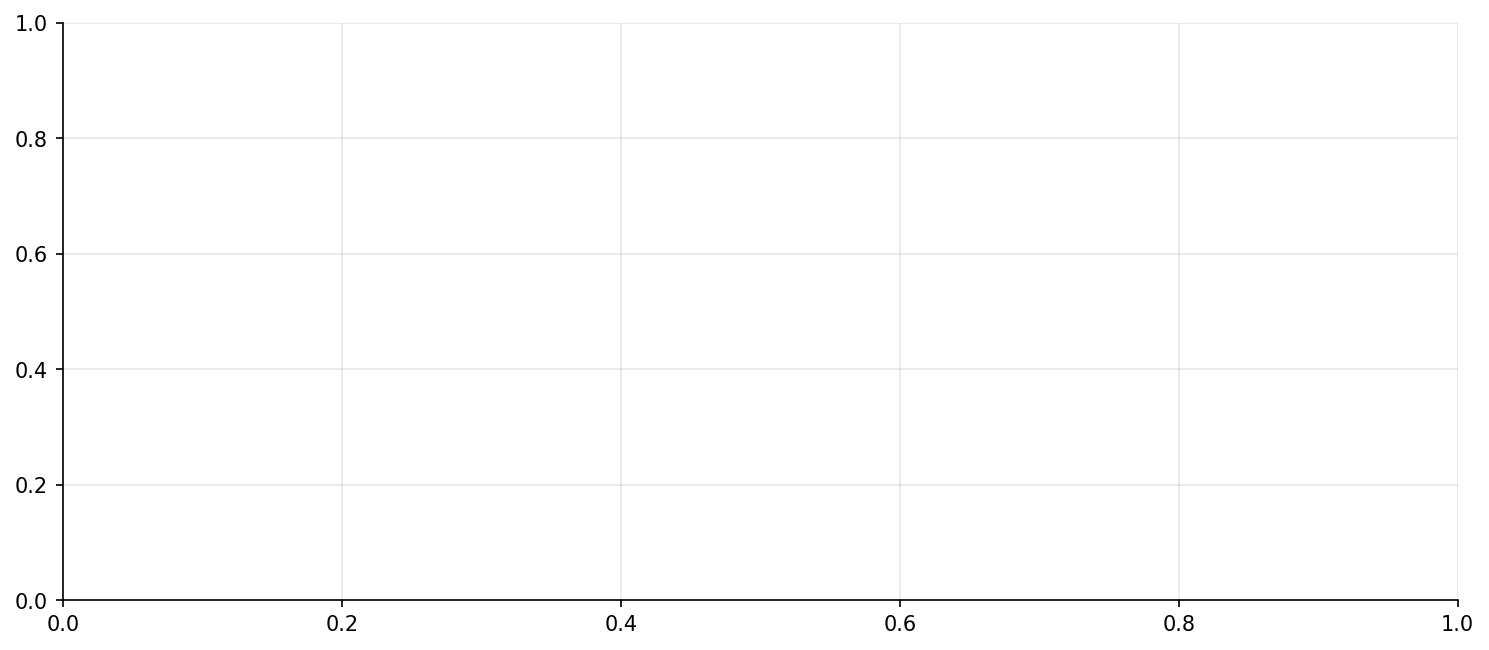

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

In [24]:
progress_order = ['On track', 'Insufficient progress', 'Off track',
                  'Data outdated', 'No data', 'Monitor (no numeric target)']
colors = [COLOR_MAP.get(p, '#888') for p in progress_order
          if p in progress_summary.columns]
cols_ordered = [p for p in progress_order if p in progress_summary.columns]

In [25]:
progress_summary[cols_ordered].plot(
    kind='barh', stacked=True, ax=ax,
    color=colors, edgecolor='white', linewidth=0.5
)

<Axes: ylabel='indicator_short'>

In [26]:
ax.set_title(
    'Country Progress Toward 2030 WHA Nutrition Targets\n'
    'UNICEF Conceptual Framework — Layer 1: Nutrition Outcomes',
    fontweight='bold'
)
ax.set_xlabel('Number of Countries')
ax.set_ylabel('')
ax.legend(loc='lower right', fontsize=8)
ax.tick_params(labelsize=9)

In [27]:
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig02_country_progress_classification.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("  Saved: fig02_country_progress_classification.png")

<Figure size 960x720 with 0 Axes>

  Saved: fig02_country_progress_classification.png


=============================================================================
FIGURE 3: Latest values map-ready table (for Tableau)
=============================================================================

In [28]:
print("\n[3] Exporting Tableau-ready datasets...")


[3] Exporting Tableau-ready datasets...


In [29]:
# Wide format: one row per country, indicators as columns (for Tableau maps)
tableau_wide = df_l1_latest.pivot_table(
    index=['iso3', 'country', 'region', 'income_group'],
    columns='indicator_short',
    values='value'
).reset_index()
tableau_wide.to_csv(f'{TABLES}/tableau_layer1_wide.csv', index=False)

In [30]:
# Long format with all metadata (for Tableau trend charts)
tableau_long = df_l1[['iso3', 'country', 'year', 'indicator', 'value',
                       'region', 'income_group']].copy()
tableau_long['indicator_short'] = tableau_long['indicator'].map(LAYER1_CODES)
tableau_long.to_csv(f'{TABLES}/tableau_layer1_long.csv', index=False)

In [31]:
# Progress classification table
df_l1_latest.to_csv(f'{TABLES}/layer1_progress_classification.csv', index=False)

In [32]:
print(f"  Saved: tableau_layer1_wide.csv ({len(tableau_wide):,} countries)")
print(f"  Saved: tableau_layer1_long.csv ({len(tableau_long):,} rows)")
print(f"  Saved: layer1_progress_classification.csv")

  Saved: tableau_layer1_wide.csv (188 countries)
  Saved: tableau_layer1_long.csv (31,560 rows)
  Saved: layer1_progress_classification.csv


=============================================================================
FIGURE 4: Data recency heatmap by region
=============================================================================

In [33]:
print("\n[4] Generating data recency heatmap...")


[4] Generating data recency heatmap...


In [34]:
df_recency = df_l1_latest.copy()
df_recency['years_since'] = 2024 - df_recency['year']

In [35]:
recency_pivot = df_recency.pivot_table(
    index='region',
    columns='indicator_short',
    values='years_since',
    aggfunc='median'
).round(1)

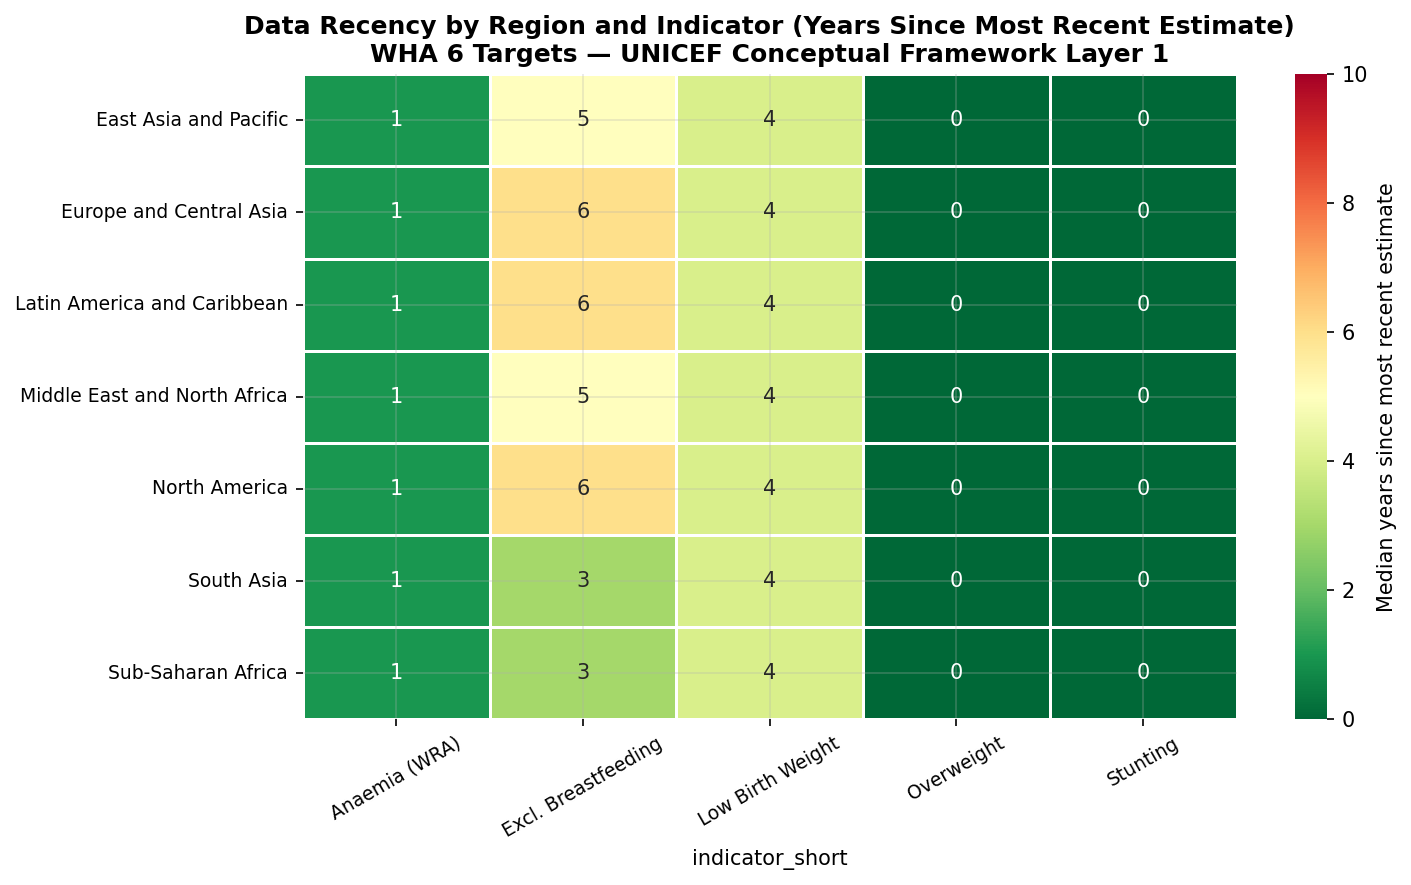

  Saved: fig03_data_recency_heatmap.png


In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    recency_pivot,
    annot=True, fmt='.0f',
    cmap='RdYlGn_r',
    vmin=0, vmax=10,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Median years since most recent estimate'}
)
ax.set_title(
    'Data Recency by Region and Indicator (Years Since Most Recent Estimate)\n'
    'WHA 6 Targets — UNICEF Conceptual Framework Layer 1',
    fontweight='bold'
)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig03_data_recency_heatmap.png',
            bbox_inches='tight', dpi=150)
plt.show()
plt.close()
print("  Saved: fig03_data_recency_heatmap.png")

In [37]:
print("\n[DONE] Notebook 02 complete. Run 03_layer2_determinants.py next.")


[DONE] Notebook 02 complete. Run 03_layer2_determinants.py next.
